In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('Titanic.csv')
print(df)


     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [17]:
sex_counts = df.groupby('Sex')['Survived'].agg(['count','sum'])
sex_counts= sex_counts.rename(columns={'sum':'Survivors'})
sex_counts['Dead'] = sex_counts['count']- sex_counts['Survivors']


In [18]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

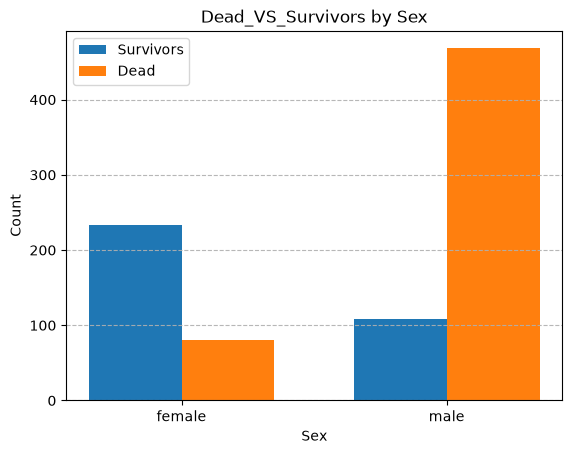

In [19]:
x_positions = range(len(sex_counts.index))
bar_width=0.35
plt.bar([i-bar_width/2 for i in x_positions],sex_counts['Survivors'], width=bar_width,label='Survivors')
plt.bar([i+bar_width/2 for i in x_positions],sex_counts['Dead'], width=bar_width,label='Dead')

plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Dead_VS_Survivors by Sex')
plt.xticks(list(x_positions),sex_counts.index)
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.9)

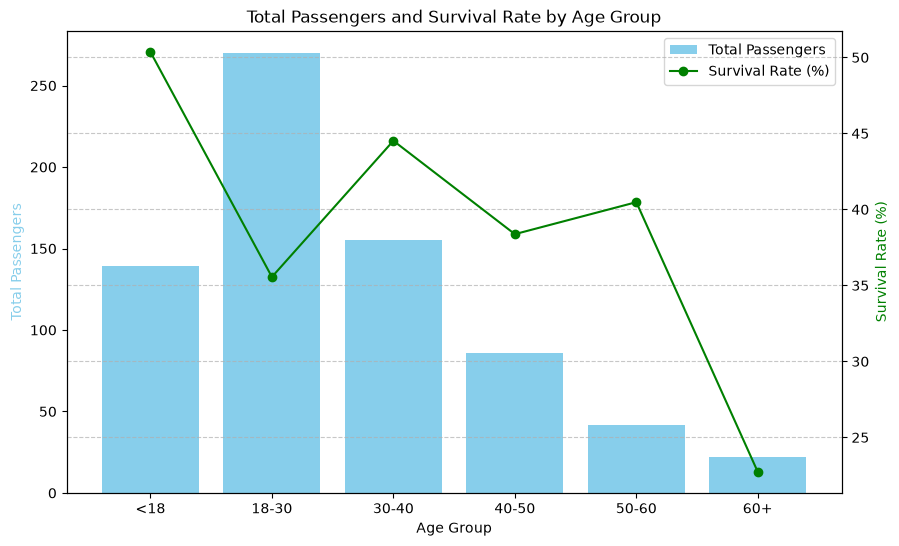

In [24]:
import pandas as pd
age_bins = [0, 18, 30, 40, 50, 60, 100]
age_labels = ['<18', '18-30', '30-40', '40-50', '50-60', '60+']

df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

age_group_data = df.groupby('AgeGroup')['Survived'].agg(['count', 'sum'])
age_group_data['SurvivalRate'] = (age_group_data['sum'] / age_group_data['count']) * 100

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(age_group_data.index, age_group_data['count'], color='skyblue', label='Total Passengers')

ax1.set_xlabel('Age Group')
ax1.set_ylabel('Total Passengers', color='skyblue')
ax1.set_title('Total Passengers and Survival Rate by Age Group')

ax2 = ax1.twinx()
ax2.plot(age_group_data.index, age_group_data['SurvivalRate'], marker='o', color='green', label='Survival Rate (%)')
ax2.set_ylabel('Survival Rate (%)', color='green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()